# CareSync Specialist Classifier (Google Colab)

This notebook trains a specialist recommendation classifier using `Healthcare_5000_with_Specialist.csv`, stores artifacts in Google Drive, and provides an optional transformer fine-tuning path.

In [10]:
# Keep Colab base scientific stack (numpy/pandas/scipy/sklearn) to avoid dependency conflicts.
# Install only NLP packages required for optional transformer fine-tuning.
import sys
!{sys.executable} -m pip install -q -U "transformers>=4.44,<5" "datasets>=2.21,<4" "accelerate>=0.34,<1" "evaluate>=0.4.3,<0.5"

if 'numpy' in sys.modules:
    print('If this cell upgraded already-imported packages, restart runtime once and rerun from top.')

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# Preferred: save directly into your project folder on Drive.
PROJECT_ROOT = Path('/content/drive/MyDrive/AI-Healthcare-Backend-System-Node.js-API-Development')
DATASET_PATH = PROJECT_ROOT / 'Healthcare_5000_with_Specialist.csv'
ARTIFACTS_DIR = PROJECT_ROOT / 'caresync-backend' / 'model_artifacts'

# Fallback paths (if project folder name differs in your Drive).
if not DATASET_PATH.exists():
    DATASET_PATH = Path('/content/drive/MyDrive/CareSync/Healthcare_5000_with_Specialist.csv')
if not ARTIFACTS_DIR.parent.exists():
    ARTIFACTS_DIR = Path('/content/drive/MyDrive/CareSync/model_artifacts')

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print('Dataset path:', DATASET_PATH)
print('Artifacts dir:', ARTIFACTS_DIR)
print('Expected backend model directory (local project): caresync-backend/model_artifacts/')

Mounted at /content/drive
Dataset path: /content/drive/MyDrive/CareSync/Healthcare_5000_with_Specialist.csv
Artifacts dir: /content/drive/MyDrive/CareSync/model_artifacts


In [3]:
import pandas as pd

df = pd.read_csv(DATASET_PATH)
print('Shape:', df.shape)
display(df.head(3))

required_cols = {'Symptoms', 'Specialist'}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f'Missing required columns: {missing}')

df = df.dropna(subset=['Symptoms', 'Specialist']).copy()
print('After cleanup:', df.shape)

Shape: (5000, 7)


,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease,Specialist
0,1,90,Male,"shortness of breath, sneezing, tremors, joint ...",5,Influenza,General Physician
1,2,11,Female,"sore throat, abdominal pain, depression, appet...",4,Tuberculosis,Pulmonologist
2,3,20,Male,"sneezing, rash, nausea, headache, abdominal pa...",7,Food Poisoning,Gastroenterologist


After cleanup: (5000, 7)


In [4]:
import re

USE_DEMOGRAPHICS = True  # Set False to train on symptoms only.

def normalize_text(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r'\s+', ' ', text)
    return text

df['symptoms_clean'] = df['Symptoms'].astype(str).apply(normalize_text)

if USE_DEMOGRAPHICS and {'Age', 'Gender'}.issubset(df.columns):
    df['feature_text'] = (
        'age=' + df['Age'].astype(str) + ' | gender=' + df['Gender'].astype(str).str.lower() +
        ' | symptoms=' + df['symptoms_clean']
    )
else:
    df['feature_text'] = 'symptoms=' + df['symptoms_clean']

label_counts = df['Specialist'].value_counts()
print('Unique specialists:', label_counts.shape[0])
display(label_counts.head(15))

Unique specialists: 15


,count
Specialist,
Neurologist,829
Pulmonologist,657
Gastroenterologist,646
Endocrinologist,526
General Physician,341
Psychiatrist,341
Cardiologist,324
Rheumatologist,174
Dermatologist,173


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

X = df['feature_text'].astype(str).values
y_raw = df['Specialist'].astype(str).values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

baseline_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=25000)),
    ('clf', LogisticRegression(max_iter=2000, n_jobs=-1))
])

baseline_pipeline.fit(X_train, y_train)
print('Baseline model trained.')

Baseline model trained.


Accuracy: 0.1390
                               precision    recall  f1-score   support

       Allergist/Immunologist       0.00      0.00      0.00        32
                 Cardiologist       0.00      0.00      0.00        65
                Dermatologist       0.00      0.00      0.00        35
               ENT Specialist       0.00      0.00      0.00        31
              Endocrinologist       0.08      0.07      0.07       105
           Gastroenterologist       0.15      0.22      0.18       129
            General Physician       0.06      0.01      0.02        68
                 Hematologist       0.00      0.00      0.00        34
                 Hepatologist       0.00      0.00      0.00        33
Infectious Disease Specialist       0.00      0.00      0.00        34
                 Nephrologist       0.00      0.00      0.00        33
                  Neurologist       0.16      0.42      0.23       166
                 Psychiatrist       0.00      0.00      0.0

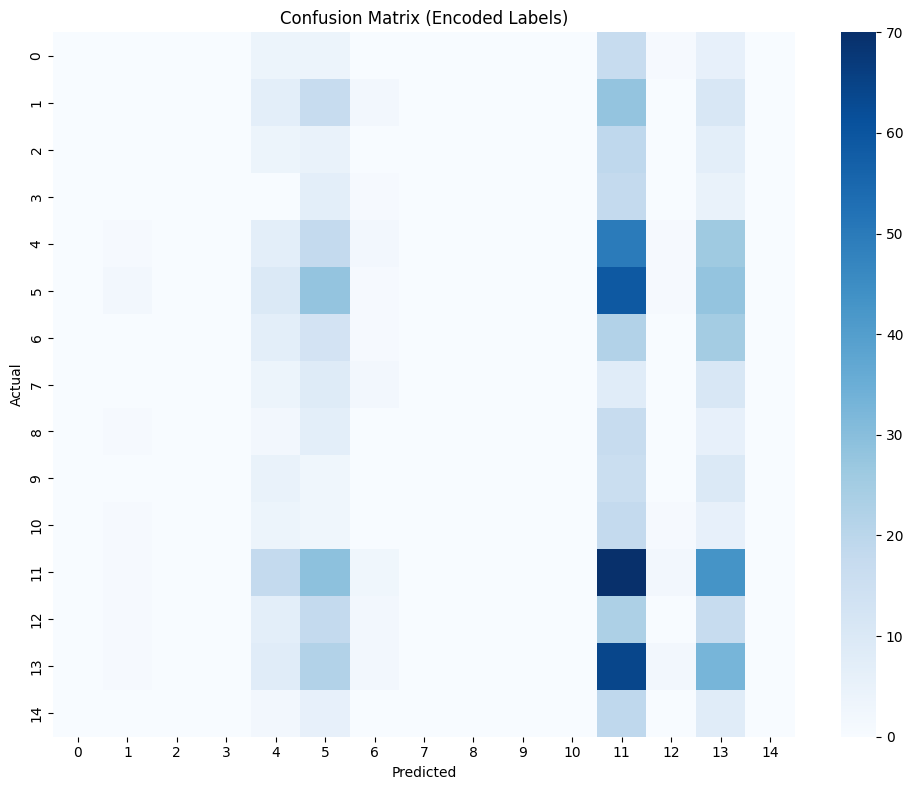

In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = baseline_pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)
MODEL_ACCURACY = float(acc)
print(f'Accuracy: {MODEL_ACCURACY:.4f} ({MODEL_ACCURACY*100:.2f}%)')

target_names = label_encoder.classes_.tolist()
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap='Blues')
plt.title('Confusion Matrix (Encoded Labels)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [7]:
import json
import joblib
from datetime import datetime

run_id = datetime.now().strftime('%Y%m%d_%H%M%S')
run_dir = ARTIFACTS_DIR / f'baseline_{run_id}'
run_dir.mkdir(parents=True, exist_ok=True)

model_path = run_dir / 'specialist_classifier.joblib'
labels_path = run_dir / 'label_encoder.joblib'
class_map_path = run_dir / 'class_labels.json'
meta_path = run_dir / 'metadata.json'

joblib.dump(baseline_pipeline, model_path)
joblib.dump(label_encoder, labels_path)

class_labels = {str(i): label for i, label in enumerate(label_encoder.classes_)}
with open(class_map_path, 'w', encoding='utf-8') as f:
    json.dump(class_labels, f, indent=2)

metadata = {
    'run_id': run_id,
    'dataset_path': str(DATASET_PATH),
    'use_demographics': USE_DEMOGRAPHICS,
    'num_samples': int(df.shape[0]),
    'num_classes': int(len(label_encoder.classes_)),
    'accuracy': float(MODEL_ACCURACY)
}
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

# Keep a stable latest folder for deployment.
latest_dir = ARTIFACTS_DIR / 'latest'
latest_dir.mkdir(parents=True, exist_ok=True)
import shutil
shutil.copy2(model_path, latest_dir / 'specialist_classifier.joblib')
shutil.copy2(labels_path, latest_dir / 'label_encoder.joblib')
shutil.copy2(class_map_path, latest_dir / 'class_labels.json')
shutil.copy2(meta_path, latest_dir / 'metadata.json')

print('Saved model artifacts to:', run_dir)
print(' -', model_path)
print(' -', labels_path)
print(' -', class_map_path)
print(' -', meta_path)
print('Latest deploy-ready folder:', latest_dir)
print('Backend target directory: caresync-backend/model_artifacts/')

Saved model artifacts to: /content/drive/MyDrive/CareSync/model_artifacts/baseline_20260518_201821
 - /content/drive/MyDrive/CareSync/model_artifacts/baseline_20260518_201821/specialist_classifier.joblib
 - /content/drive/MyDrive/CareSync/model_artifacts/baseline_20260518_201821/label_encoder.joblib
 - /content/drive/MyDrive/CareSync/model_artifacts/baseline_20260518_201821/class_labels.json
 - /content/drive/MyDrive/CareSync/model_artifacts/baseline_20260518_201821/metadata.json


In [8]:
def predict_specialist(symptoms, age=None, gender=None):
    symptoms = normalize_text(symptoms)
    if USE_DEMOGRAPHICS and age is not None and gender is not None:
        text = f'age={age} | gender={str(gender).lower()} | symptoms={symptoms}'
    else:
        text = f'symptoms={symptoms}'

    probs = baseline_pipeline.predict_proba([text])[0]
    pred_idx = int(probs.argmax())
    label = label_encoder.inverse_transform([pred_idx])[0]
    return {
        'predicted_specialist': label,
        'confidence': float(probs[pred_idx])
    }

sample = predict_specialist('fever, cough, shortness of breath', age=34, gender='Female')
print(sample)

{'predicted_specialist': 'Neurologist', 'confidence': 0.17820400787869667}


## Accuracy + model placement

- Baseline model accuracy is printed in the evaluation cell.
- The same value is stored in `metadata.json`.
- Copy files from `ARTIFACTS_DIR/latest/` into your backend folder:
  - `caresync-backend/model_artifacts/specialist_classifier.joblib`
  - `caresync-backend/model_artifacts/label_encoder.joblib`
  - `caresync-backend/model_artifacts/class_labels.json`
  - `caresync-backend/model_artifacts/metadata.json`

## Optional: transformer fine-tuning (toggle)

Set `RUN_FINE_TUNE = True` only when you have enough Colab GPU time and want to compare against the baseline model. Baseline artifacts are enough for backend integration.

In [16]:
RUN_FINE_TUNE = True

if RUN_FINE_TUNE:
    from datasets import Dataset
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
    import numpy as np
    import evaluate

    model_name = 'distilbert-base-uncased'
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_df = pd.DataFrame({'text': X_train, 'label': y_train})
    test_df = pd.DataFrame({'text': X_test, 'label': y_test})
    train_ds = Dataset.from_pandas(train_df)
    test_ds = Dataset.from_pandas(test_df)

    def tokenize_fn(batch):
        return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=256)

    train_ds = train_ds.map(tokenize_fn, batched=True)
    test_ds = test_ds.map(tokenize_fn, batched=True)
    train_ds = train_ds.remove_columns([c for c in train_ds.column_names if c not in ['input_ids', 'attention_mask', 'label']])
    test_ds = test_ds.remove_columns([c for c in test_ds.column_names if c not in ['input_ids', 'attention_mask', 'label']])

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(label_encoder.classes_))
    metric_acc = evaluate.load('accuracy')
    metric_f1 = evaluate.load('f1')

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {
            'accuracy': metric_acc.compute(predictions=preds, references=labels)['accuracy'],
            'f1_macro': metric_f1.compute(predictions=preds, references=labels, average='macro')['f1']
        }

    ft_dir = ARTIFACTS_DIR / f'transformer_{run_id}'
    args = TrainingArguments(
        output_dir=str(ft_dir),
        eval_strategy='epoch',
        save_strategy='epoch',
        logging_steps=50,
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro'
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        processing_class=tokenizer,
        compute_metrics=compute_metrics
    )

    trainer.train()
    eval_metrics = trainer.evaluate()
    print(eval_metrics)
    trainer.save_model(str(ft_dir / 'model'))
    tokenizer.save_pretrained(str(ft_dir / 'tokenizer'))
    print('Fine-tuned artifacts saved to:', ft_dir)
else:
    print('RUN_FINE_TUNE=False -> skipping transformer fine-tuning.')

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,2.527272,2.519885,0.166000,0.018982
2,2.507188,2.519042,0.166000,0.018982
3,2.500807,2.517571,0.166000,0.018982


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
2.500807,2.519885,3,0.166000,0.018982


{'eval_loss': 2.5198848247528076, 'eval_accuracy': 0.166, 'eval_f1_macro': 0.01898227558604917}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned artifacts saved to: /content/drive/MyDrive/CareSync/model_artifacts/transformer_20260518_201821
